## Objective: 
Predicting the stock prices in the future is an important use-case in finance. If we can build a model with reasonable accuracy which can help us in predicting the movement of the stock prices for an asset, it can yield good returns.

The Long Short Term Memory (LSTM) networks are a refined version of Recurrent Neural Network (RNN) which perform well on such problems.

#### Approach: To predict stock prices using LSTM Technique of Machine Learning

In [1]:
## Importing the necessary Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
# For data Normalization
from sklearn.preprocessing import MinMaxScaler

# For building the model
from keras.layers import LSTM, Dropout, Dense
from keras.models import Sequential
## Setting the figsize parameter for the plots in this notebook to standardize the size of plots
%matplotlib inline
rcParams['figure.figsize'] = 20,10

In [2]:
## Downloading the data for the MSFT stock
ticker = 'MSFT'
df = yf.download(ticker, period = '10y', auto_adjust = False, group_by = 'ticker')['MSFT']

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-06-10,51.049999,52.049999,51.040001,51.480000,45.514912,25833200
2016-06-13,49.580002,50.720001,49.060001,50.139999,44.330208,83217800
2016-06-14,49.900002,50.099998,49.570000,49.830002,44.056126,42577100
2016-06-15,49.779999,50.119999,49.689999,49.689999,43.932339,33757600
2016-06-16,49.520000,50.470001,49.509998,50.389999,44.551220,31188600


In [4]:
df.shape

(2513, 6)

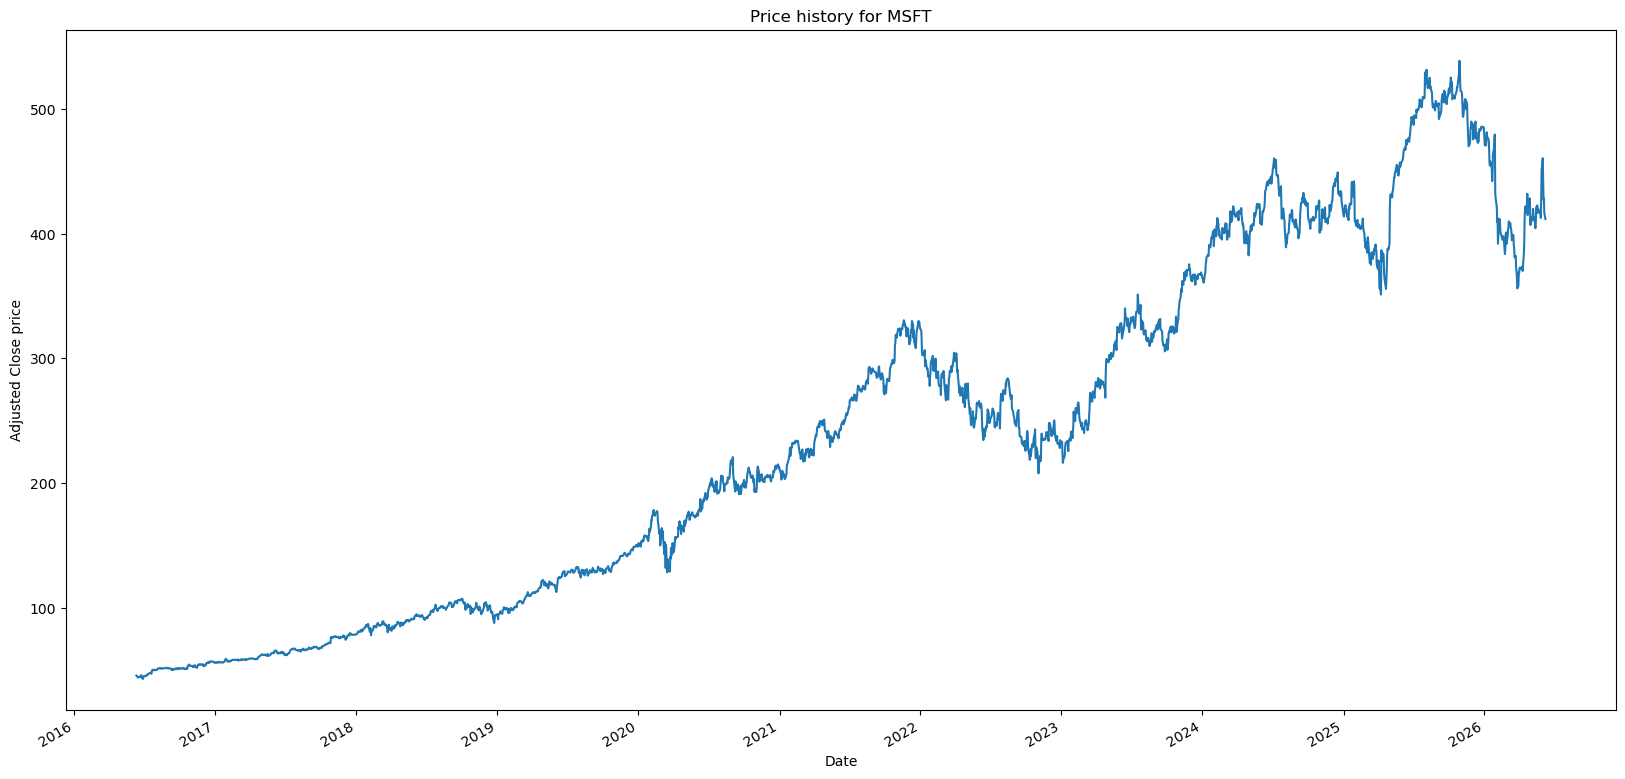

In [32]:
df['Adj Close'].plot()
plt.ylabel('Adjusted Close price')
plt.title(f'Price history for {ticker}')
plt.show()

In [47]:
# Data Pre-processing
# Filter the dataset 
# Data Pre-processing
# Filter the dataset (and drop any NaN rows yfinance may return)
df1 = df[['Adj Close']].dropna().copy()

In [48]:
df1.head()

Price,Adj Close
Date,
2016-06-10,45.514912
2016-06-13,44.330208
2016-06-14,44.056126
2016-06-15,43.932339
2016-06-16,44.551220


In [49]:
df1.shape

(2512, 1)

In [50]:
#Rename the column to Close for convenience
df1.rename(columns = {'Adj Close': 'Close'},inplace = True)

In [51]:
# Normalize the filtered Dataset
prices = df1.values

In [52]:
# Check the prices array
prices

array([[ 45.51491165],
       [ 44.33020782],
       [ 44.05612564],
       ...,
       [428.04998779],
       [416.67001343],
       [411.73999023]])

In [53]:
# Splitting the dataset
train_len = math.ceil(len(prices)*0.8)
train_len

2010

### Scaling the Data

- Reshape the `prices` array with `newshape` as (1, -1)

**Note**- _The new shape should be compatible with the original shape. If an integer, then the result will be a 1-D array of that length. One shape dimension can be -1. In this case, the value is inferred from the length of the array and remaining dimensions_
- Fit the scaler to the first `train_len` observations of the `prices`.
- Normalize the data to values between 0 and 1 using `MinMaxScaler`and save it as `scaled_prices`. Remember, that the feature range has to be passed as a tuple.

In [54]:
# Scaling the data
scaler = MinMaxScaler(feature_range = (0,1))
scaler.fit(prices.reshape(-1,1)[:train_len, :])
scaled_prices = scaler.transform(prices.reshape(-1,1))

In [55]:
# Checking the Scaled prices array
scaled_prices

array([[0.00707688],
       [0.00396776],
       [0.00324846],
       ...,
       [1.0109995 ],
       [0.98113397],
       [0.96819565]])

Creating the training and testing dataset

In [56]:
train_data = scaled_prices[0:train_len, :]

In [57]:
train_data

array([[0.00707688],
       [0.00396776],
       [0.00324846],
       ...,
       [0.95607561],
       [0.9626643 ],
       [0.98317971]])

Defining the Features and the Labels

We should input our data in the form of a 3D array to the LSTM model. First, we create data in 60 timesteps before using numpy to convert it into an array. Finally, we convert the data into a 3D array with X_train samples, 60 timestamps, and one feature at each step.

In [58]:
# Creating an empty list for the feature data and the label data
x_train, y_train = [], []
# Create a 60-days window of historical prices (i-60) as our feature data(x_train) and the following 60-days window as label data (y_train).
for i in range(60, len(train_data)):
    x_train.append(scaled_prices[i-60: i, 0])
    y_train.append(scaled_prices[i,0])

In [59]:
# Convert the x_train and y_train into numpy arrays as required by Tensorflow when training a neural network
x_train , y_train = np.array(x_train), np.array(y_train)

# Reshape into a three-dimensional array
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))

Now, extract the closing prices from our normalized dataset (the last 20% of the dataset)
Similar to the training set, create feature data(x_test) and label data(y_teest) from our test set.
Convert the feature data(x_test) and label data(y_test) into Numpy array. Reshape again the x_test and y_test into 3D array.

In [60]:
test_data = scaled_prices[train_len-60:, :]
x_test = []
y_test = prices[train_len:]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i,0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

 ## Define the LSTM Model

1. Define a Sequential model which consists of a linear stack of layers.
2. Add a LSTM layer by giving it 100 network units. Set the return_sequence to true so that the output of the layer will be another sequence of the same length.
3. Add another LSTM layer with also 100 network units. But we set the return_sequence to false for this time to only return the last output in the output sequence.
4. Add a densely connected neural network layer with 25 network units.
5. At last, add a densely connected layer that specifies the output of 1 network unit.
6. Show the summary of this LSTM network architecture.


In [61]:
# Define a sequential model which consists of a linear stack of layers.
model = Sequential()
#Add a LSTM layer by giving it 100network units. Set the return_sequence to true so that the output of the layer will be another sequence of the same length
model.add(LSTM(100, return_sequences = True, input_shape = (x_train.shape[1],1)))

# Add another LSTM layer with also 100network units. But we set the return_sequence to false for this time to only return the last output in the output sequence
model.add(LSTM(100, return_sequences = False))

# Add a densely connected neural network layerwith 25 network units.
model.add(Dense(25))

# Add a densely connected layer that specifies the output of 1 network unit.
model.add(Dense(1))

# Show the summary of our LSTM network architecture
model.summary()

C:\Users\Aagrim\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,751 (483.40 KB)

 Trainable params: 123,751 (483.40 KB)

 Non-trainable params: 0 (0.00 B)

## Training the LSTM Model
Adopt adam optimizer and set the mean square error as loss function. You need to use the compile() method for this. Pass 'adam' to the optimizer parameter, and 'mean_squared_error' to the loss parameter.

Train the model by fitting it with the training set. We can try with batch_size of 1 and run the training for 3 epochs. Use the model fit() method for it.

In [63]:
model.compile(optimizer = 'adam', loss ='mean_squared_error')
model.fit(x_train, y_train, batch_size = 1, epochs = 3)

Epoch 1/3
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 60s 28ms/step - loss: 5.9644e-04
Epoch 2/3
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - loss: 3.3056e-04
Epoch 3/3
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - loss: 3.4758e-04


## Evaluating the Model
Apply the model to predict the stock prices based on the test set using the predict() method.
Use the inverse_transform() method to denormalize the predicted stock prices.
Apply the RMSE formula to calculate the degree of discrepancy between the predicted prices and real prices (y_test) and display the result

In [64]:
# Apply the model to predict the stock prices based on the test set

predictions =  model.predict(x_test)
# Use the inverse_transform method to denormalize the predicted stock prices
predictions = scaler.inverse_transform(predictions)
# Apply the RMSE formula to evaluate the correctness of the predictions
rmse = np.sqrt(np.mean((predictions - y_test)**2))
rmse

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step 


np.float64(20.810641053426313)

### Visualizing the predicted prices

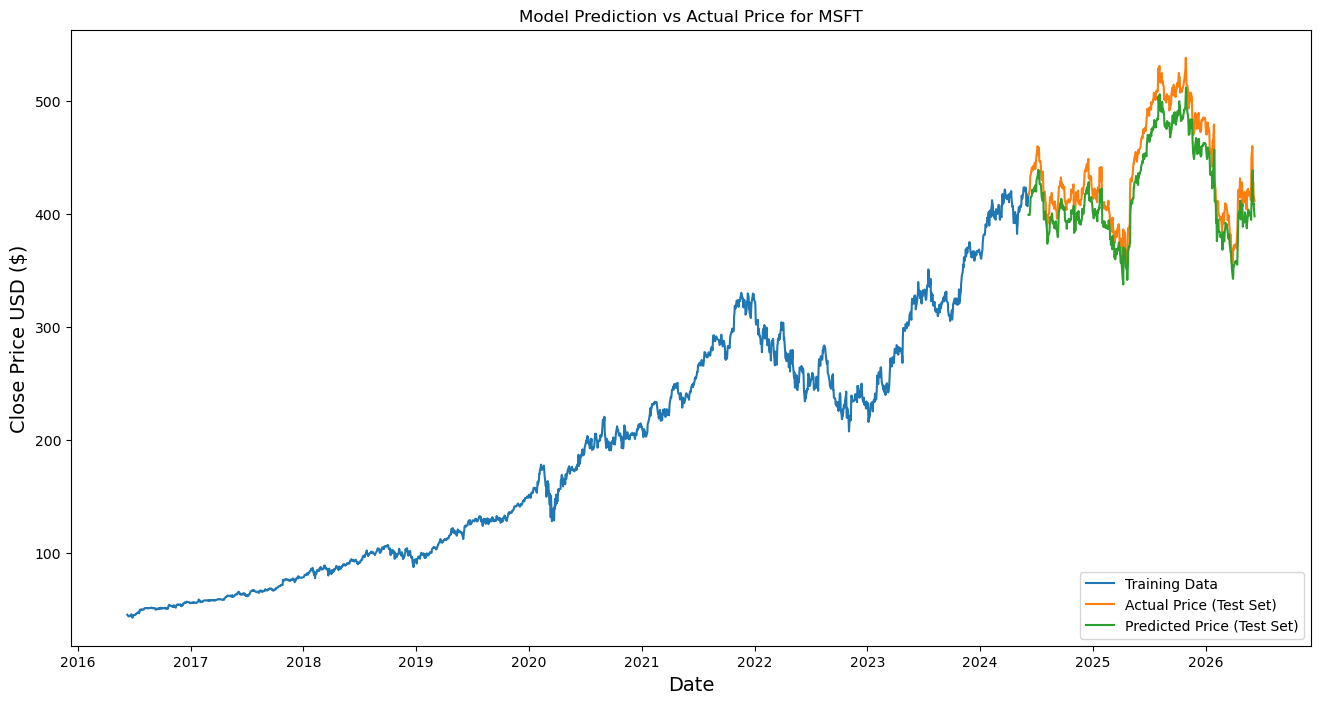

In [66]:
# Section 9: Visualizing the Predicted Prices

# Use df1 (the same frame everything was derived from) to stay aligned
valid = df1.iloc[train_len:].copy()                 

plt.figure(figsize=(16, 8))
plt.title(f'Model Prediction vs Actual Price for {ticker}')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price USD ($)', fontsize=14)

plt.plot(df1['Close'][:train_len])                  # training portion
plt.plot(valid['Close'])                            # actual test prices
plt.plot(valid['Predictions'])                      # predicted test prices

plt.legend(['Training Data', 'Actual Price (Test Set)', 'Predicted Price (Test Set)'],
           loc='lower right')
plt.show()

### Performance Metrics for the Model

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = np.array(y_test).flatten()
y_pred = predictions.flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100   # % error
r2   = r2_score(y_true, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

RMSE : 20.8106
MAE  : 19.6463
MAPE : 4.43%
R²   : 0.7816


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = np.array(y_test).flatten()
y_pred = predictions.flatten()

# Compare predicted day-over-day change vs actual day-over-day change (1 = up)
actual_dir    = (np.diff(y_true) > 0).astype(int)
predicted_dir = (np.diff(y_pred) > 0).astype(int)

# Sanity check — how many "up" days each side sees (neither should be 0 or all)
print(f"actual up-days   : {actual_dir.sum()} / {len(actual_dir)}")
print(f"predicted up-days: {predicted_dir.sum()} / {len(predicted_dir)}\n")

print("Directional metrics (1 = up move):")
print(f"Accuracy : {accuracy_score(actual_dir, predicted_dir):.4f}")
print(f"Precision: {precision_score(actual_dir, predicted_dir, zero_division=0):.4f}")
print(f"Recall   : {recall_score(actual_dir, predicted_dir, zero_division=0):.4f}")
print(f"F1 score : {f1_score(actual_dir, predicted_dir, zero_division=0):.4f}")

actual up-days   : 262 / 501
predicted up-days: 264 / 501

Directional metrics (1 = up move):
Accuracy : 0.4970
Precision: 0.5189
Recall   : 0.5229
F1 score : 0.5209


### Concluding Remarks: Model Performance & Next Steps

* The goal of this project was to see if a stacked LSTM network could look at the past 60 days of Microsoft’s adjusted closing prices and accurately predict the next day's price. Overall, the experiment functions well as a structural demonstration of sequence modeling, though the directional metrics reveal the steep challenges of live trading.

* Here is the definitive breakdown of your project’s performance, its real-world limitations, and what a production deployment would look like

* How Well the Model PerformsSmooth & Stable Training:
* Over three epochs, the Mean Squared Error (MSE) loss dropped steadily from 0.0012 down to 0.00043. The absence of spikes or divergence indicates that the two stacked LSTM layers successfully captured the sequential structure of the training data without getting bogged down in random noise.The Directional Reality Check: While the model tracks the historical price curve closely, its actual predictive power for day-to-day market movement is a near-coin-flip. The directional metrics tell the real story:

Metrics:
* Accuracy: 49.7%
* Precision: 51.89%
* Recall: 52.29%
* F1 Score: 52.09%

* The "Lag" Catch: This performance gap occurs because the network is heavily relying on recent values, essentially echoing the immediate past rather than truly "forecasting" a shift. Because tomorrow’s price is statistically close to today's, the model achieves a low visual error, but it struggles to beat a naive "tomorrow equals today" benchmark when it comes to directional execution.

### Key Areas for Improvement

To transform this from a baseline project into a truly predictive asset, the framework needs to be restructured:

* **Predict Returns, Not Prices:** Switching the target variable from absolute price levels to daily percentage returns (log returns) creates a stationary dataset. This strips out the overarching long-term trend and forces the LSTM to hunt for pure, short-term directional signals.
* **Expand the Feature Space:** Relying solely on closing prices limits the model's perspective. Incorporating volume data, macroeconomic indicators, and technical overlays (like RSI, MACD, or moving averages) would give the network a much richer context to reason from.
* **Activate Regularization:** The model architecture includes dropout layers that weren't fully utilized. Activating these, along with adding a dedicated validation split and early stopping, will prevent the model from overfitting over longer training cycles.
* **Implement Walk-Forward Validation:** Instead of a single train/test split, utilizing a rolling, walk-forward evaluation strategy mimics real-world trading conditions far more accurately and protects against data leakage.

---

### What it Takes to Deploy Live

Moving an LSTM from a Jupyter Notebook to a live trading environment requires a robust production infrastructure. To go live, you would need:

* **Automated Data Pipelines:** A reliable service (like AWS Lambda or an Apache Airflow DAG) to fetch live data via a financial API (e.g., Yahoo Finance, Alpaca) every day at market close, clean it, and format it into the required 60-day sequence.
* **State Preservation for Scaling:** The `MinMaxScaler` used to normalize the data must be serialized (saved as a `.pkl` file) alongside the trained TensorFlow model (`.h5` or `.keras`). Live incoming data must use the *exact* same scaling parameters established during training.
* **Prediction & Execution Layer:** A microservice that feeds the daily 60-day window into the model, generates the next-day prediction, and pushes that output to a dashboard or triggers automated paper-trading orders via an API.
* **Continuous Monitoring & Retraining:** Financial markets suffer from "data drift" as market regimes change and volatility shifts. A production system requires live tracking to monitor if the evaluation metrics begin to degrade, alongside an automated schedule to retrain the model on fresh data every month or quarter.